# Milestone 2: ViT registers reproduction (run on Google Colab)

This notebook runs the whole pipeline for this milestone, top to bottom:

1. **Tests**: check that our model and measurement code behave correctly
2. **Data + forward pass check**: download Tiny-ImageNet, run one batch through our ViT (0 and 4 registers)
3. **Sanity training**: short runs on a small subset, to show the training loop learns
4. **Part A**: reproduce the paper's findings on Meta's pretrained DINOv2 models
5. **Download**: zip all results so they can be uploaded to GitHub

**Before running:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`. Takes about 30–40 minutes.

## 0. Setup: get the code

In [1]:
import os

REPO_URL = "https://github.com/recommended131225435/vit-registers-reproduction"  # <-- change to your repo

if os.path.exists("../src") and not os.path.exists("src"):  # opened from inside notebooks/
    %cd ..
if not os.path.exists("src"):                                  # fresh Colab session
    !git clone -q {REPO_URL} repo
    %cd repo
!pip install -q -r requirements.txt

import torch
from IPython.display import Image, Markdown, display
print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE (switch runtime to T4!)")

/content/repo
torch 2.11.0+cu128 | GPU: Tesla T4


## 1. Tests

In [2]:
!python -m pytest -q

.........                                                                [100%]
9 passed in 5.64s


## 2. Data pipeline + forward pass check (Week 3 deliverable)

In [3]:
!python -m scripts.check_forward_pass

100% 248M/248M [00:05<00:00, 43.3MB/s]
[PASS] Train set size  100,000 images
[PASS] Val set size  10,000 images
[PASS] Train batch shape  (64, 3, 64, 64)
[PASS] Val batch shape  (64, 3, 64, 64)
[PASS] Labels in [0, 199]  min 0, max 197
[PASS] Pixels normalised (mean near 0, std near 1)  mean -0.110, std 1.170
[PASS] [0 reg] logits shape  (64, 200)
[PASS] [0 reg] loss is finite  5.3739
[PASS] [0 reg] starting loss close to ln(200)  5.374 vs 5.298
[PASS] [0 reg] every parameter gets a finite gradient  
[PASS] [0 reg] sequence length = 1 + R + 64  65 = 1 + 0 + 64
[PASS] [0 reg] registers split off at output  reg (64, 0, 192), patch (64, 64, 192)
[PASS] [0 reg] attention weights sum to 1  attention shape (64, 3, 65, 65)
[PASS] [0 reg] step-by-step attention == fast attention  max difference 4.8e-07
[PASS] [4 reg] logits shape  (64, 200)
[PASS] [4 reg] loss is finite  5.2905
[PASS] [4 reg] starting loss close to ln(200)  5.291 vs 5.298
[PASS] [4 reg] every parameter gets a finite gradient  

Data: Tiny-ImageNet. Model: ViT-Tiny (192-dim, 12 blocks, 3 heads, 8x8 patches, 64 patch tokens). Batch size 64. Device `cuda` (Tesla T4), Python 3.13.15, torch 2.11.0+cu128.

| Check | Result | Detail |
|---|---|---|
| Train set size | PASS | 100,000 images |
| Val set size | PASS | 10,000 images |
| Train batch shape | PASS | (64, 3, 64, 64) |
| Val batch shape | PASS | (64, 3, 64, 64) |
| Labels in [0, 199] | PASS | min 0, max 197 |
| Pixels normalised (mean near 0, std near 1) | PASS | mean -0.110, std 1.170 |
| [0 reg] logits shape | PASS | (64, 200) |
| [0 reg] loss is finite | PASS | 5.3739 |
| [0 reg] starting loss close to ln(200) | PASS | 5.374 vs 5.298 |
| [0 reg] every parameter gets a finite gradient | PASS |  |
| [0 reg] sequence length = 1 + R + 64 | PASS | 65 = 1 + 0 + 64 |
| [0 reg] registers split off at output | PASS | reg (64, 0, 192), patch (64, 64, 192) |
| [0 reg] attention weights sum to 1 | PASS | attention shape (64, 3, 65, 65) |
| [0 reg] step-by-step attention == fast attention | PASS | max difference 4.8e-07 |
| [4 reg] logits shape | PASS | (64, 200) |
| [4 reg] loss is finite | PASS | 5.2905 |
| [4 reg] starting loss close to ln(200) | PASS | 5.291 vs 5.298 |
| [4 reg] every parameter gets a finite gradient | PASS |  |
| [4 reg] registers receive gradient | PASS | grad norm 2.59e+00 |
| [4 reg] sequence length = 1 + R + 64 | PASS | 69 = 1 + 4 + 64 |
| [4 reg] registers split off at output | PASS | reg (64, 4, 192), patch (64, 64, 192) |
| [4 reg] attention weights sum to 1 | PASS | attention shape (64, 3, 69, 69) |
| [4 reg] step-by-step attention == fast attention | PASS | max difference 9.5e-07 |
| Registers add exactly R x 192 parameters | PASS | 5,427,080 -> 5,427,848 (+768) |

**24/24 checks passed.**


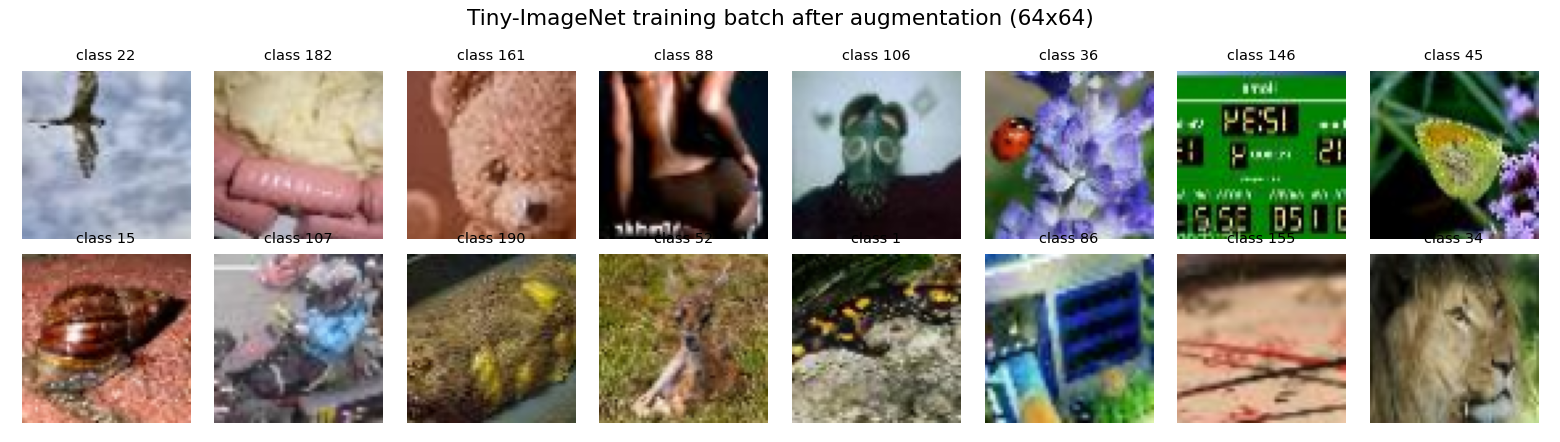

In [4]:
display(Markdown(open("results/logs/forward_pass_check.md").read()))
display(Image("results/figures/tinyimagenet_samples.png"))

## 3. Sanity training runs
ViT-Tiny, 10k training images, 5 epochs, 0 vs 4 registers. Loss should go down. These are not results, only a check that training works.

In [5]:
!python -m src.train --registers 0 --epochs 5 --train-subset 10000 --val-subset 2000 --out results/runs/sanity_tiny_reg0
!python -m src.train --registers 4 --epochs 5 --train-subset 10000 --val-subset 2000 --out results/runs/sanity_tiny_reg4

Tiny-ImageNet already present at data/tiny-imagenet-200
tiny ViT | 0 registers | 5,427,080 params | device cuda
epoch   1 | train loss 5.188 acc 0.015 | val loss 5.113 acc 0.021 | 11s
epoch   2 | train loss 5.060 acc 0.029 | val loss 5.047 acc 0.021 | 10s
epoch   3 | train loss 4.995 acc 0.029 | val loss 4.991 acc 0.028 | 9s
epoch   4 | train loss 4.931 acc 0.040 | val loss 4.967 acc 0.034 | 10s
epoch   5 | train loss 4.880 acc 0.046 | val loss 4.952 acc 0.035 | 10s
final: {'val_acc': 0.0355, 'val_loss': 4.95184415435791, 'epochs_run': 5, 'steps': 195}
Tiny-ImageNet already present at data/tiny-imagenet-200
tiny ViT | 4 registers | 5,427,848 params | device cuda
epoch   1 | train loss 5.187 acc 0.015 | val loss 5.105 acc 0.025 | 10s
epoch   2 | train loss 5.054 acc 0.026 | val loss 5.037 acc 0.024 | 10s
epoch   3 | train loss 4.983 acc 0.033 | val loss 4.990 acc 0.030 | 10s
epoch   4 | train loss 4.908 acc 0.042 | val loss 4.941 acc 0.037 | 9s
epoch   5 | train loss 4.859 acc 0.051 | v

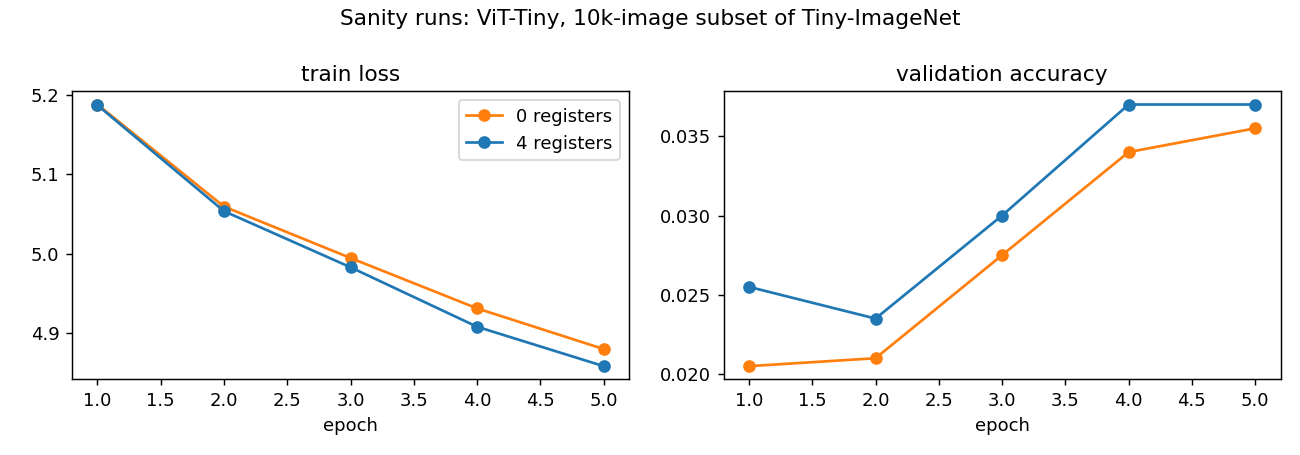

In [6]:
from src.plots import plot_training_curves

plot_training_curves(
    {"0 registers": "results/runs/sanity_tiny_reg0", "4 registers": "results/runs/sanity_tiny_reg4"},
    "results/figures/sanity_runs.png",
    "Sanity runs: ViT-Tiny, 10k-image subset of Tiny-ImageNet",
)
display(Image("results/figures/sanity_runs.png"))

## 4. Part A: artifacts in pretrained DINOv2 (no training)
Downloads 8 models (S, B, L, g, each with and without registers). If Colab runs out of memory on the giant model, change `S,B,L,g` to `S,B,L` and run the cell again.

In [7]:
!python -m scripts.run_part_a --sizes S,B,L,g

100% 342M/342M [00:07<00:00, 46.8MB/s]
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth
100% 84.2M/84.2M [00:00<00:00, 358MB/s]
Running dinov2_vits14 ...
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
D

Setup: official DINOv2 checkpoints (torch.hub), 256 Imagenette validation images at 224x224 (256 patches each). Norms are measured on the output of the last transformer block, before the final LayerNorm. An outlier is a patch token whose norm is more than 3 x the median norm of the same model.

| Model | Median norm (no reg / 4 reg) | Max norm (no reg / 4 reg) | % outliers, no reg | % outliers, 4 reg | Neighbour similarity, outlier vs normal (no reg) |
|---|---|---|---|---|---|
| ViT-S/14 | 20.1 / 58.8 | 29.7 / 88.6 | 0.00% | 0.00% | n/a vs 0.615 |
| ViT-B/14 | 53.9 / 138.9 | 252.2 / 216.8 | 0.20% | 0.00% | 0.884 vs 0.608 |
| ViT-L/14 | 84.7 / 254.8 | 145.2 / 420.4 | 0.00% | 0.00% | n/a vs 0.502 |
| ViT-g/14 | 49.6 / 107.8 | 560.6 / 286.7 | 2.62% | 0.00% | 0.871 vs 0.662 |

With the paper's own cutoff (norm > 150) on ViT-g: **2.62%** of patch tokens without registers (paper reports 2.37%). This cutoff is only meaningful for the no-register model, which is what the paper applied it to.

Why before the final LayerNorm: the LayerNorm rescales every token to a similar length. Largest token norm divided by the median norm:

| Model | before LayerNorm (no reg / 4 reg) | after LayerNorm (no reg / 4 reg) |
|---|---|---|
| ViT-S/14 | 1.48x / 1.51x | 1.17x / 1.28x |
| ViT-B/14 | 4.68x / 1.56x | 1.41x / 1.20x |
| ViT-L/14 | 1.71x / 1.65x | 1.24x / 1.19x |
| ViT-g/14 | 11.30x / 2.66x | 1.08x / 1.11x |

Average norms in the register models, before the final LayerNorm (where do the high norms go? cf. paper Fig 15b):

| Model | [CLS] | reg_0 | reg_1 | reg_2 | reg_3 | median patch |
|---|---|---|---|---|---|---|
| ViT-S/14 + reg | 42.7 | 43.9 | 159.8 | 42.4 | 40.1 | 58.8 |
| ViT-B/14 + reg | 132.7 | 104.5 | 230.1 | 104.5 | 284.5 | 138.9 |
| ViT-L/14 + reg | 196.7 | 762.2 | 128.1 | 170.0 | 170.4 | 254.8 |
| ViT-g/14 + reg | 150.9 | 299.2 | 150.7 | 1389.6 | 64.4 | 107.8 |

Figures: `results/figures/part_a_*.png`


**part_a_norm_histograms**

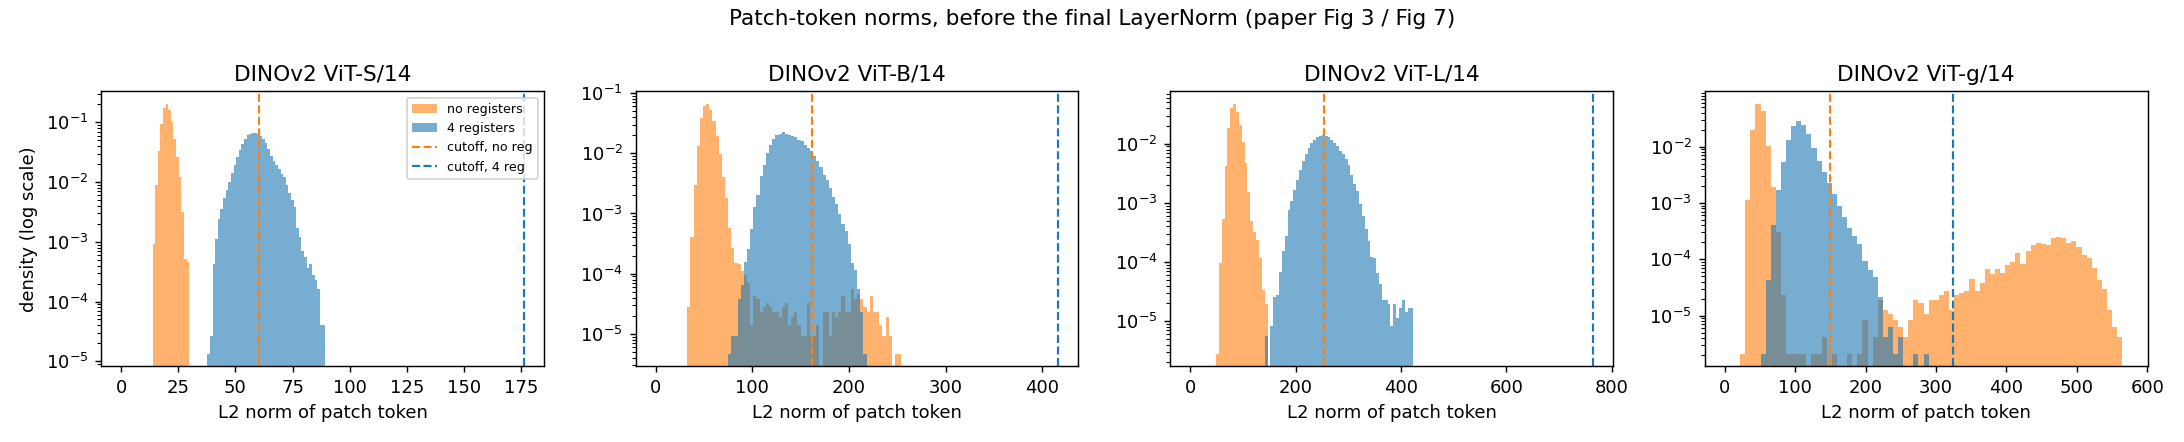

**part_a_outliers_by_size**

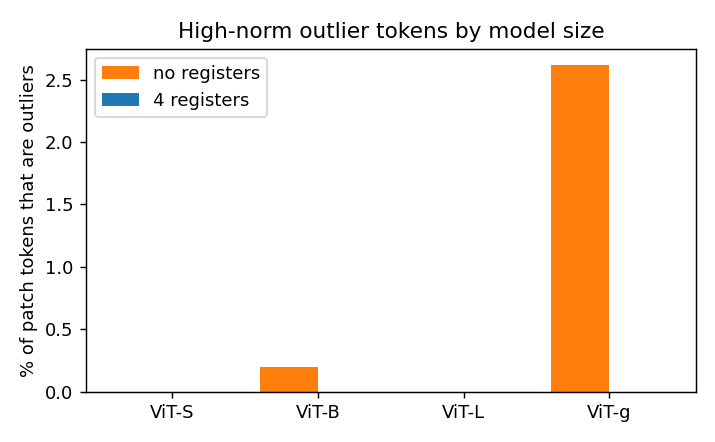

**part_a_neighbour_cosine**

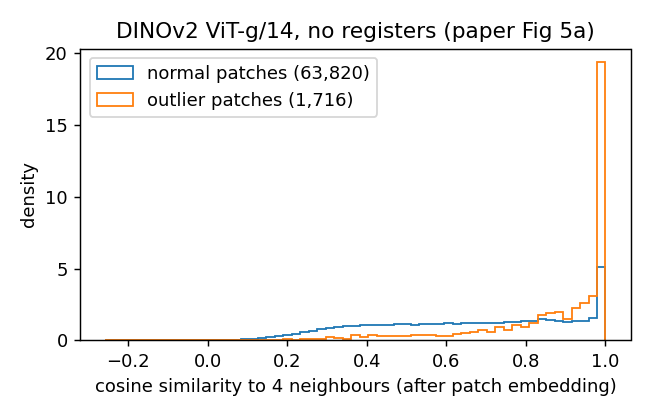

**part_a_attention_maps**

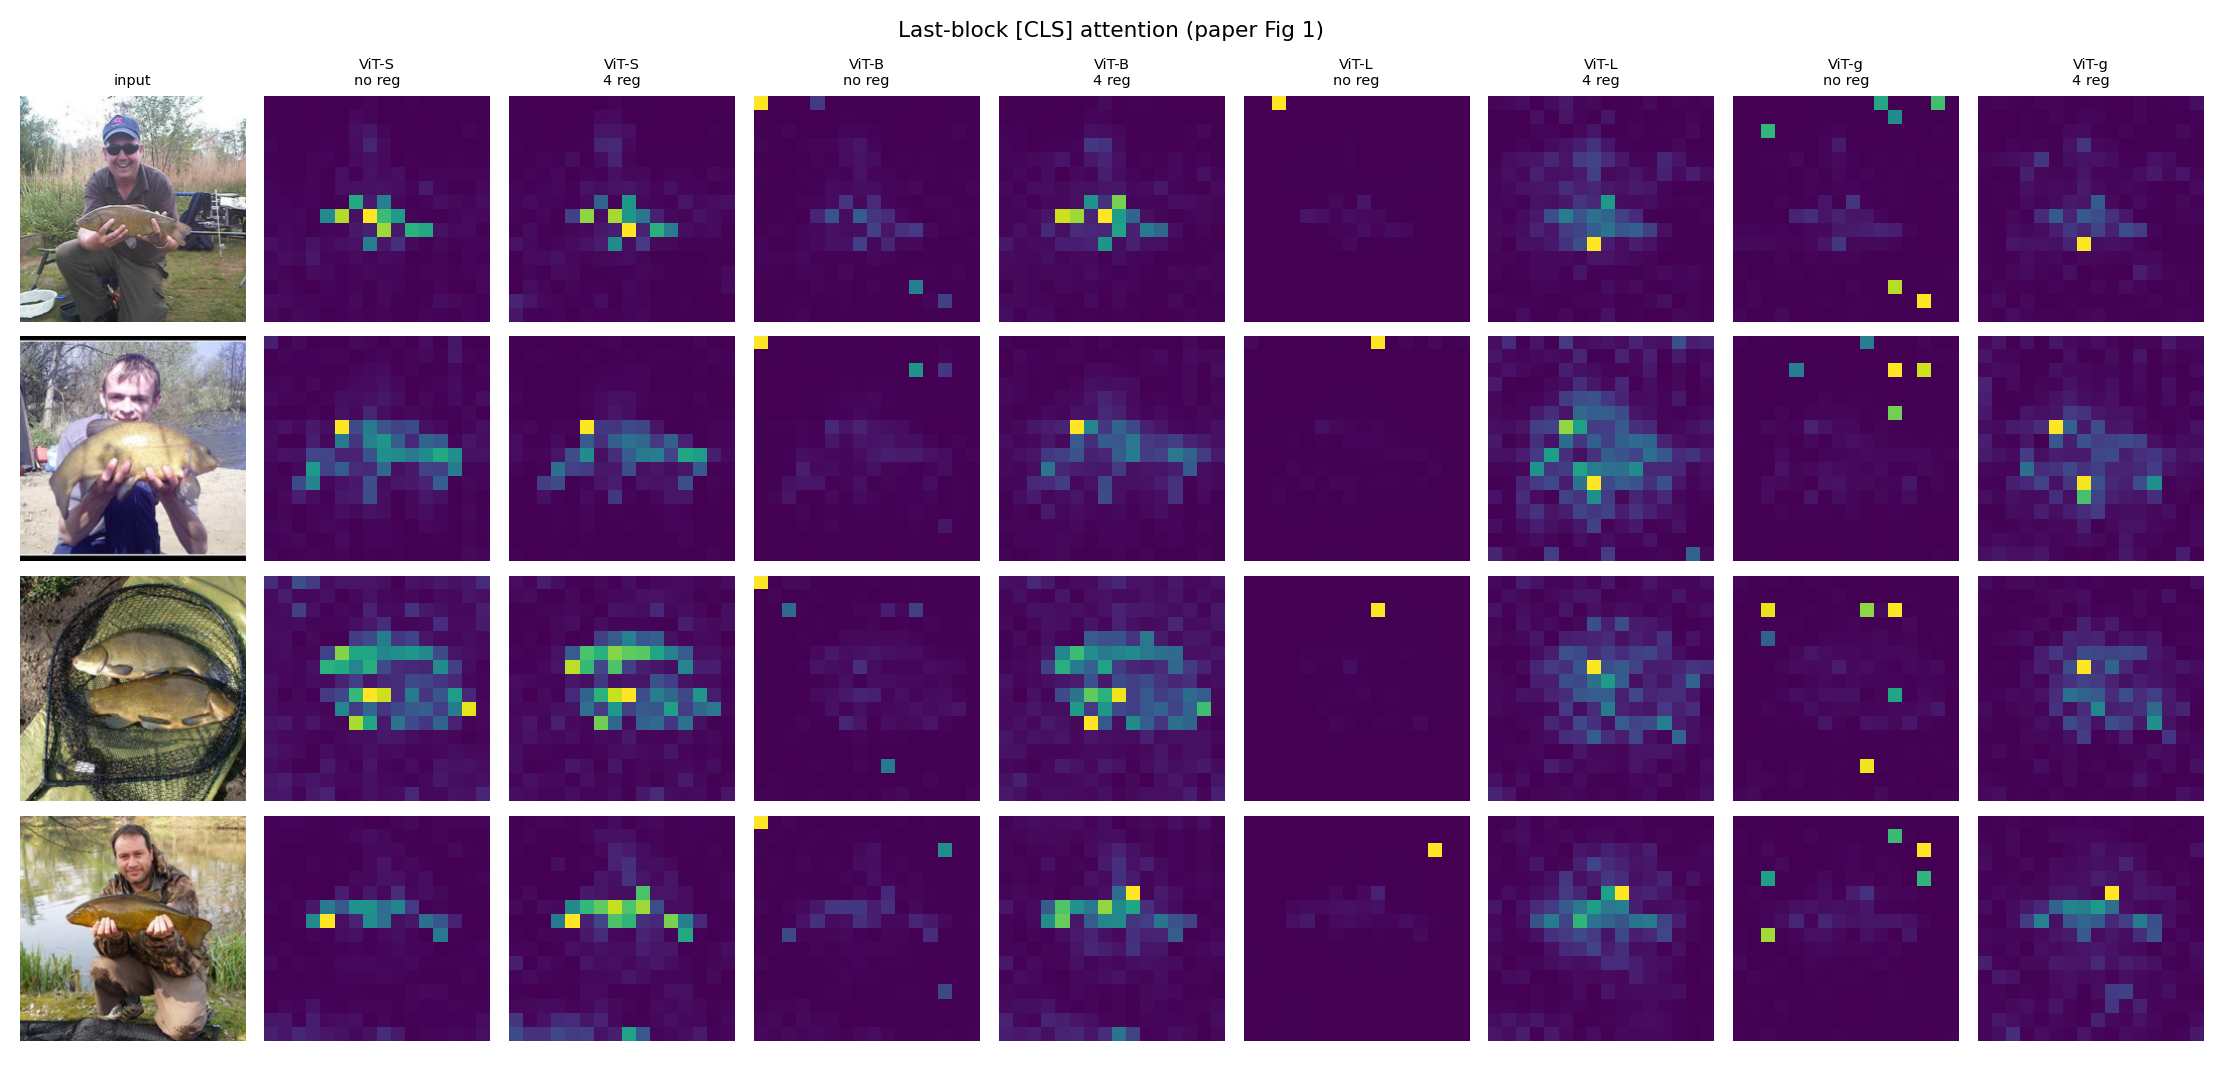

**part_a_norm_maps**

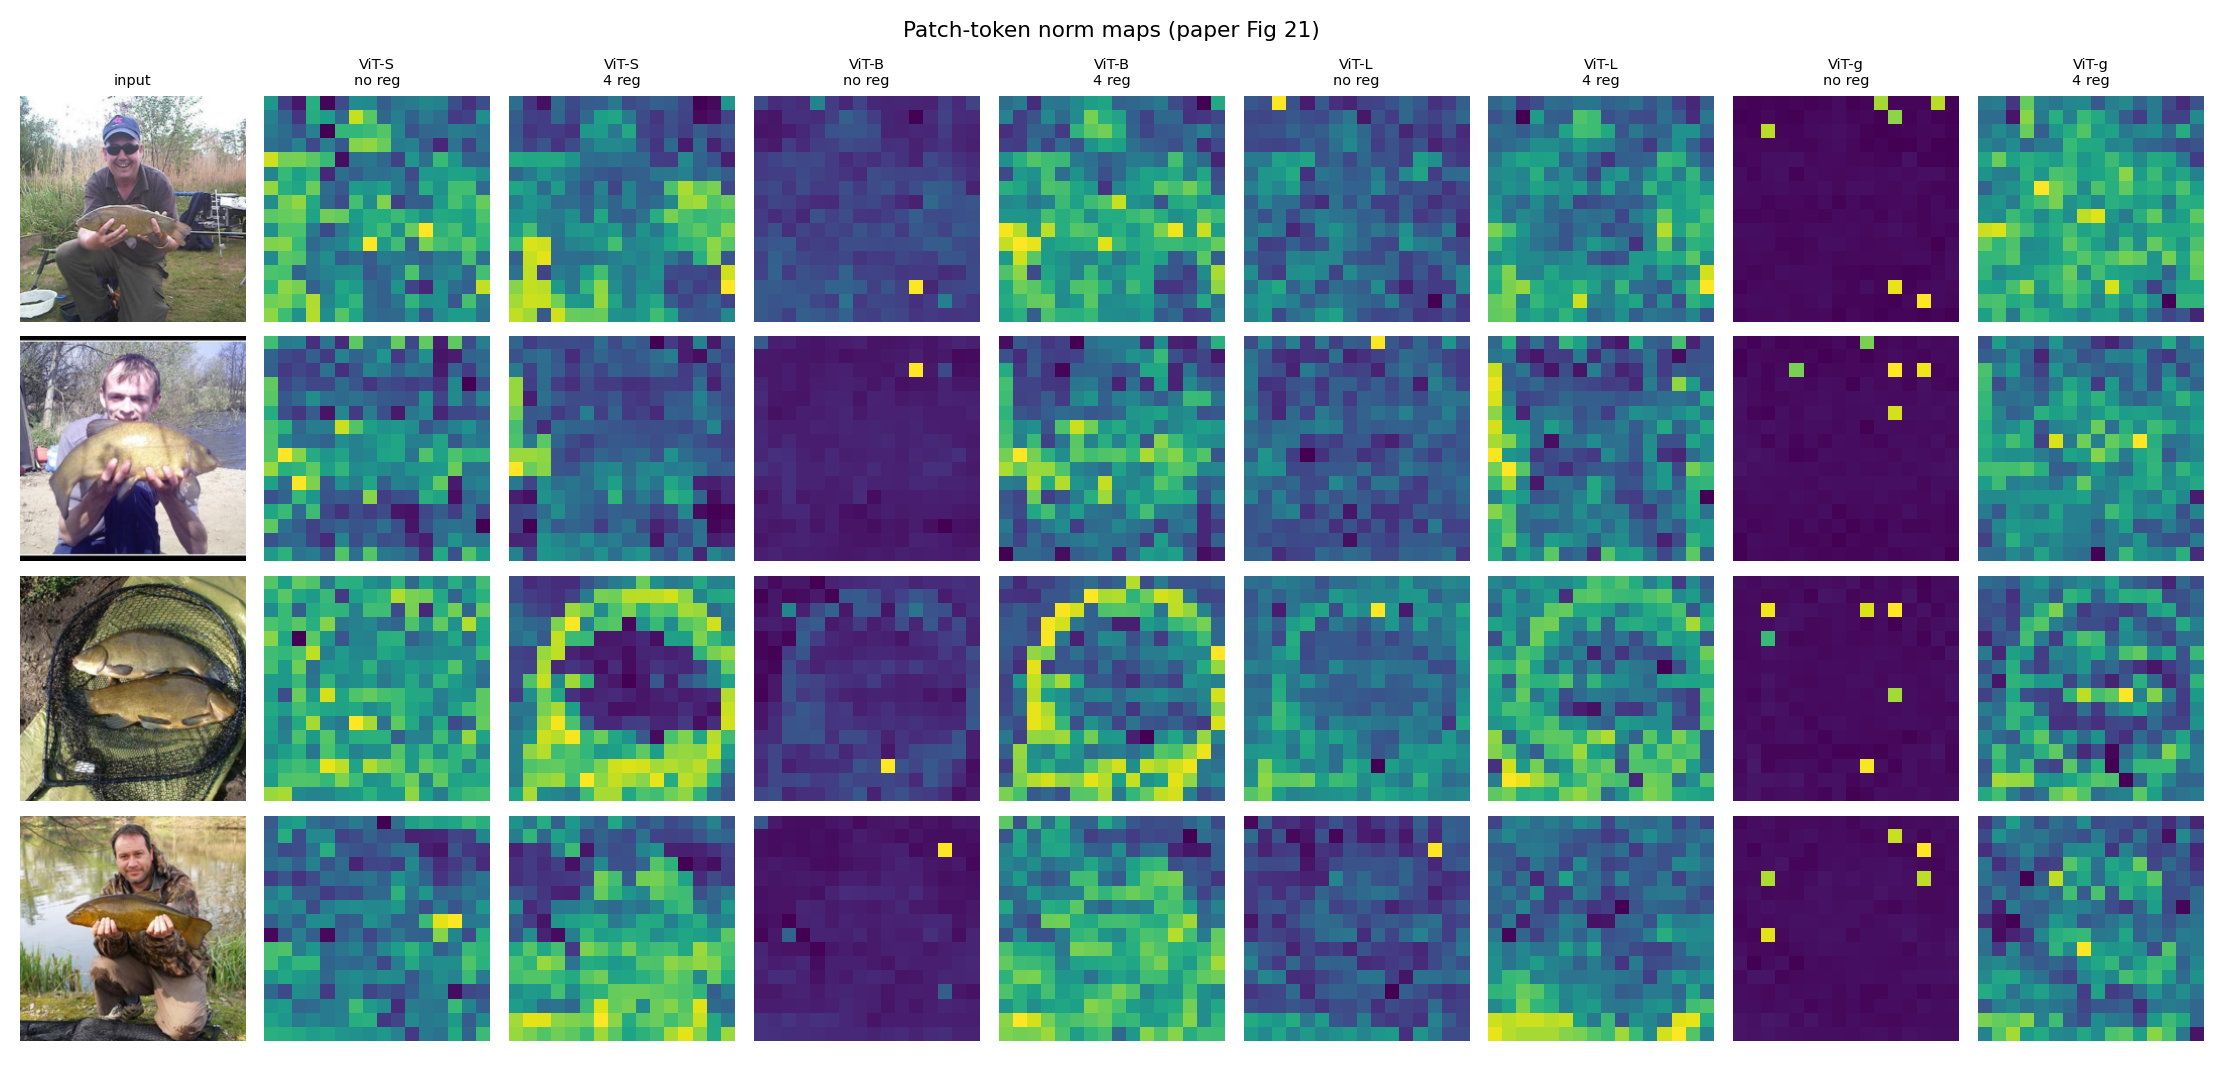

**part_a_norm_histograms_after_layernorm**

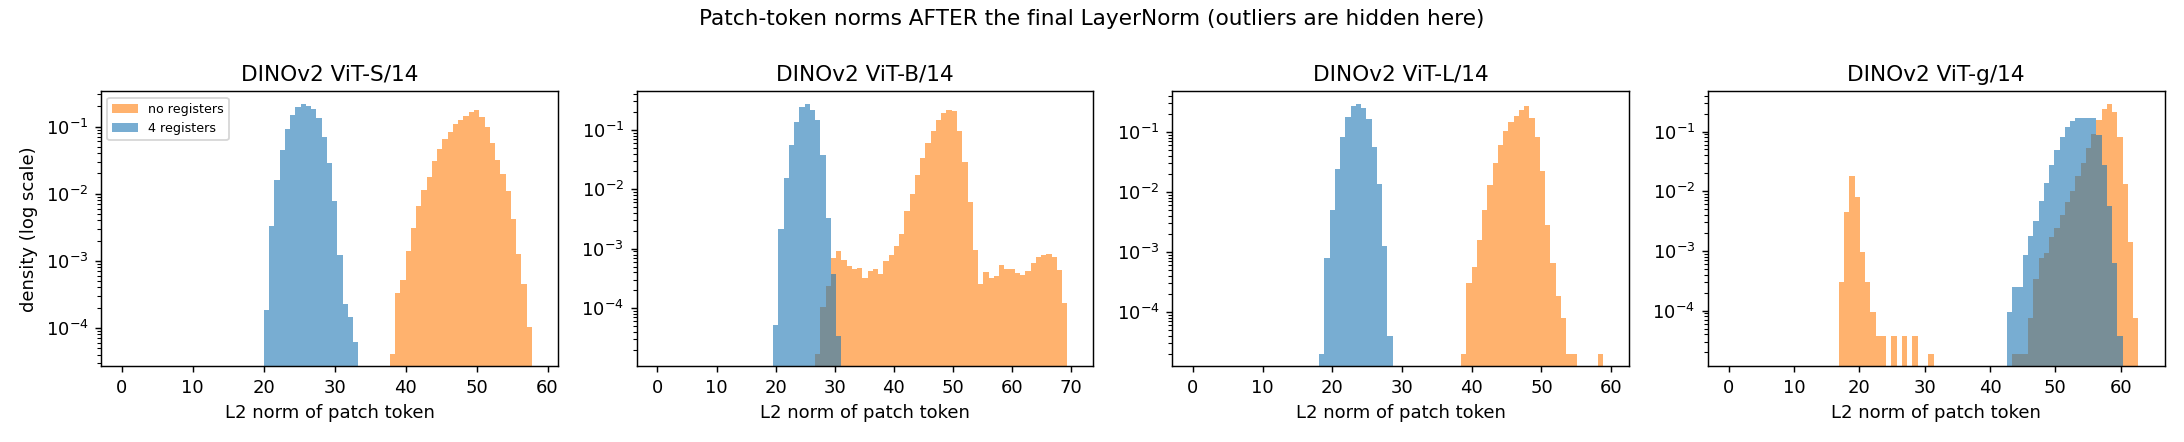

In [8]:
display(Markdown(open("results/part_a/summary.md").read()))
for name in ["norm_histograms", "outliers_by_size", "neighbour_cosine",
             "attention_maps", "norm_maps", "norm_histograms_after_layernorm"]:
    display(Markdown(f"**part_a_{name}**"))
    display(Image(f"results/figures/part_a_{name}.png"))

## 5. Save exact library versions and download everything

In [9]:
!pip freeze | grep -iE "^(torch|torchvision|numpy|matplotlib|pytest)==" > requirements-lock.txt
!cat requirements-lock.txt
!rm -f results/runs/*/checkpoint.pt    # model weights are too big for GitHub; not needed yet
!zip -qr milestone2_results.zip results README.md requirements-lock.txt

try:
    from google.colab import files
    files.download("milestone2_results.zip")
except ImportError:
    print("Not on Colab: milestone2_results.zip is in", os.getcwd())

matplotlib==3.10.0
numpy==2.1.3
pytest==8.4.2
torch==2.11.0+cu128
torchvision==0.26.0+cu128


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>